<a href="https://www.kaggle.com/code/michaelnabil88/en-ar-translation?scriptVersionId=316044470" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 1. Defining Tokenizer, Loading, Filterning and Preprocessing Text

In [ ]:
def train_bpe_tokenizer(sentences, vocab_size=10000, save_path="tokenizer.json"):
    """
    Trains a BPE tokenizer from scratch to strictly control the embedding matrix size.
    """
    # Initialize a Byte-Pair Encoding model
    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.pre_tokenizer = Whitespace()
    
    # Define special tokens required for Seq2Seq
    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["[PAD]", "[UNK]", "[SOS]", "[EOS]"]
    )
    
    # Train directly on the in-memory list of sentences
    tokenizer.train_from_iterator(sentences, trainer=trainer)
    tokenizer.save(save_path)
    
    return tokenizer

In [11]:
import re
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm

import pandas as pd
import urllib.request
import io
# ==========================================
# 1. Advanced Cleaners & Filters
# ==========================================
def comprehensive_cleaner(text, is_arabic=True):
    """Removes noise, normalizes Arabic, and squashes whitespace."""
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', '<URL>', text)
    
    if is_arabic:
        text = re.sub(r'[\u064B-\u065F]', '', text) # Diacritics
        text = re.sub(r'\u0640', '', text)         # Tatweel
        text = re.sub(r'[إأآا]', 'ا', text)        # Alif
        text = re.sub(r'ى', 'ي', text)             # Alef Maksura
        text = re.sub(r'ة', 'ه', text)             # Taa Marbuta
        text = re.sub(r'[«»]', '"', text)          # Quotes
        text = re.sub(r'،', ',', text)             # Comma
        text = re.sub(r'؟', '?', text)             # Question mark
        eastern_to_western = str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789')
        text = text.translate(eastern_to_western)
        
    # Standardize multiple hyphens to a single dash, and multiple dots to a standard ellipsis
    # It standardizes the punctuation so the BPE tokenizer doesn't waste vocabulary slots on variations like '--', '---', '..', and '....'.
    text = re.sub(r'-{2,}', '-', text)  # Turns '--' or '---' into '-'
    text = re.sub(r'\.{2,}', '...', text) # Turns '..' or '....' into '...'
    
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def is_valid_alphabet(en_text, ar_text):
    """Drops pairs containing Chinese, Hindi, Russian, etc."""
    # Allows Latin, numbers, punctuation
    en_pattern = re.compile(r'^[a-zA-Z0-9\s\.,!\?\'"()\-:;/%$€]+$')
    # Allows Arabic, numbers, punctuation
    ar_pattern = re.compile(r'^[\u0600-\u06FF0-9\s\.,!\?\'"()\-:;/%$€]+$')
    
    if en_pattern.match(en_text) and ar_pattern.match(ar_text):
        return True
    return False

# ==========================================
# 2. Dataset Gathering
# ==========================================
def extract_hf_pairs(hf_repo, config_name, num_samples):
    """Safely extracts data from Hugging Face Parquet datasets."""
    dataset = load_dataset(hf_repo, config_name, split="train", streaming=True)
    shuffled = dataset.shuffle(seed=42, buffer_size=10000)
    
    en_list, ar_list = [], []
    sample_iterator = iter(shuffled)
    
    with tqdm(total=num_samples, desc=f"Fetching {hf_repo}") as pbar:
        while len(en_list) < num_samples:
            try:
                row = next(sample_iterator)
                if 'translation' in row:
                    en_text = row['translation']['en']
                    ar_text = row['translation']['ar']
                else:
                    en_text = row.get('en', '')
                    ar_text = row.get('ar', '')
                
                if en_text and ar_text:
                    en_list.append(en_text)
                    ar_list.append(ar_text)
                    pbar.update(1)
            except StopIteration:
                print(f"Warning: Reached end of dataset before hitting {num_samples} samples.")
                break
                
    return en_list, ar_list

def build_and_filter_master_dataset(custom_file_path=None, max_len=30):
    """Builds the raw dataset and immediately applies all strict filters."""
    raw_en = []
    raw_ar = []
    
    # 1. OPUS-100 (Subtitles, TED, Gen Text) - 80k
    en, ar = extract_hf_pairs("Helsinki-NLP/opus-100", "ar-en", 80000)
    raw_en.extend(en); raw_ar.extend(ar)
    
    # 2. News Commentary (Formal MSA) - 20k
    en, ar = extract_hf_pairs("news_commentary", "ar-en", 20000)
    raw_en.extend(en); raw_ar.extend(ar)
    
    # 3. Custom Local Dataset
    if custom_file_path:
        try:
            custom_df = pd.read_csv(custom_file_path, sep='\t', header=None, names=['en', 'ar']).dropna()
            raw_en.extend(custom_df['en'].astype(str).tolist())
            raw_ar.extend(custom_df['ar'].astype(str).tolist())
            print(f"Added {len(custom_df)} pairs from local file.")
        except Exception as e:
            print(f"Could not load local file: {e}")

    print(f"\n--- Starting Aggressive Filtering on {len(raw_en)} raw pairs ---")
    
    final_en = []
    final_ar = []

    invalid_pairs_count = 0
    for en, ar in tqdm(zip(raw_en, raw_ar), total=len(raw_en), desc="Cleaning & Filtering"):
        # Step A: Clean strings
        clean_en = comprehensive_cleaner(en, is_arabic=False)
        clean_ar = comprehensive_cleaner(ar, is_arabic=True)
        
        # Step B: Drop foreign alphabets
        if not is_valid_alphabet(clean_en, clean_ar):
            invalid_pairs_count += 1
            continue
            
        # Step C: Word bounds (<= 30) AND Character bounds (> 1) to drop empty/dash pairs
        en_words = clean_en.split()
        ar_words = clean_ar.split()
        
        if 0 < len(en_words) <= max_len and 0 < len(ar_words) <= max_len:
            if len(clean_en) > 1 and len(clean_ar) > 1:
                final_en.append(clean_en)
                final_ar.append(clean_ar)
    print(f"\nInvalid pairs count = {invalid_pairs_count}")            
    print(f"\nPipeline Complete! Yielded {len(final_en)} pristine, NMT-ready pairs.")
    return final_en, final_ar

# ==========================================
# 3. Execution
# ==========================================
if __name__ == "__main__":
    # Change "my_custom_dataset.txt" to your actual file name, or pass None
    url = "https://raw.githubusercontent.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/master/ara_.txt"
    response = urllib.request.urlopen(url)
    raw_text = response.read().decode('utf-8')
    # Convert string to file-like object
    custom_file = io.StringIO(raw_text)
    final_en_data, final_ar_data = build_and_filter_master_dataset(custom_file)
    
    # You now pass final_en_data and final_ar_data directly into your 
    # train_test_split() and Tokenizer training block!

README.md: 0.00B [00:00, ?B/s]

Fetching Helsinki-NLP/opus-100: 100%|██████████| 80000/80000 [00:11<00:00, 6850.45it/s]


README.md: 0.00B [00:00, ?B/s]

Fetching news_commentary: 100%|██████████| 20000/20000 [00:04<00:00, 4219.90it/s]


Added 10742 pairs from local file.

--- Starting Aggressive Filtering on 110742 raw pairs ---


Cleaning & Filtering: 100%|██████████| 110742/110742 [00:06<00:00, 16532.10it/s]


Invalid pairs count = 17417

Pipeline Complete! Yielded 83171 pristine, NMT-ready pairs.


In [108]:
TRAINING_PAIRS_COUNT = len(final_en_data)
SOURCES = {"Helsinki-NLP/opus-100": 80000,
           "news_commentary": 20000,
           "github.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/blob/master/ara_.txt": 10000
          }
print(TRAINING_PAIRS_COUNT)


83171


### Before applying standardization on the number of Hyphens and Dots:

In [84]:
two_or_more_hyphens = []
two_or_more_dots = []
for sentence in final_en_data:
    if '--' in sentence:
        two_or_more_hyphens.append(sentence)
    if '..' in sentence:
        two_or_more_dots.append(sentence)
print("Number of sentences having two or more Hyphens",len(two_or_more_hyphens))
print("Number of sentences having two or more Dots",len(two_or_more_dots))

Number of sentences having two or more Hyphens 405
Number of sentences having two or more Dots 4078


In [87]:
print("Sample of sentences having two or more Hyphens, with count = ",len(two_or_more_hyphens))
suspecious_sentences[:50]

Sample of sentences having two or more Hyphens, with count =  405


['You get little pieces of green paper called money...',
 "You shouldn't.. Let him read it.",
 'Pah get out of here fast..',
 '- Yeah... - Yeah?',
 'He filled her with poison and began speaking in tongue... satanic words.',
 'Sir..',
 "Don't you touch my...!",
 'But...',
 'Either I get a text, or an e-mail, or something official...',
 'Mary Todd... will you make me the happiest of men?',
 'New York, London, Paris, Beijing... and...',
 'Ca...',
 'Well... do--uh...',
 "You're so angry that...",
 'michael Jackson, Gene kelly...',
 'I could fall in love with you, you know. Uh...',
 'So...',
 "You... you're obviously very nice for...",
 'Centaur...',
 'Toby Follet fromAnjuna..',
 "I mean, we've been going out for years, and all of a sudden... bang... she drops me.",
 'You have that right, but if...',
 'Otherwise...',
 'Well, desperate times...',
 "Yeah, the folks at Global Tetrahedron thought he'd be... you know, a fun, unobtrusive way to plug the company during the news.",
 'Sir, if... loo

### After Applying Standardization

In [ ]:
two_or_more_hyphens = []
two_or_more_dots = []
for sentence in final_en_data:
    if '--' in sentence:
        two_or_more_hyphens.append(sentence)
    if '..' in sentence:
        two_or_more_dots.append(sentence)
print("Number of sentences having two or more Hyphens",len(two_or_more_hyphens))
print("Number of sentences having two or more Dots",len(two_or_more_dots))

In [64]:
en_sentences_length = []
ar_sentences_length = []
for i in range(len(final_en_data)):
    en_sentences_length.append(len(final_en_data[i].split()))
    ar_sentences_length.append(len(final_ar_data[i].split()))

### Plotting the Count of sentences with each Length of words, from 1 to 30

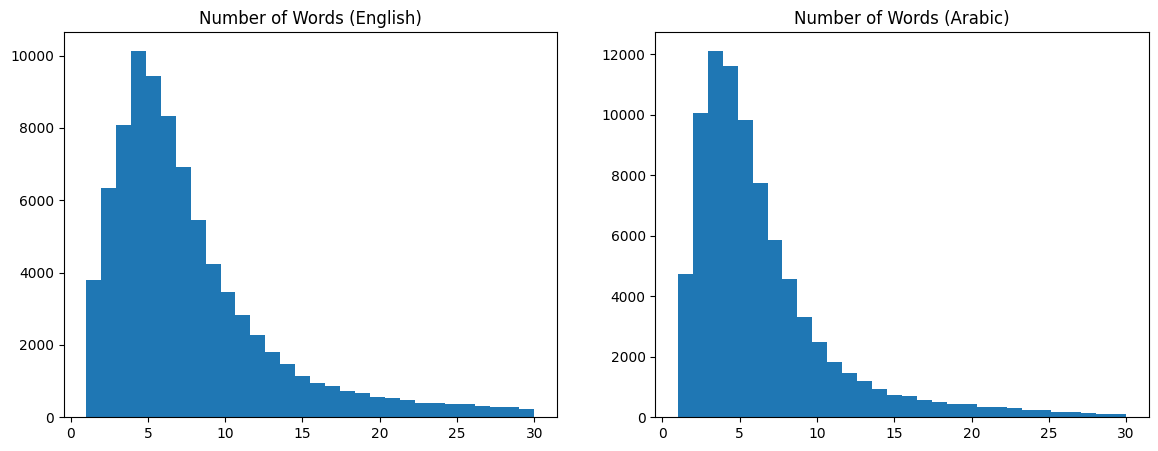

In [105]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(en_sentences_length, bins=30)
axes[0].set_title("Number of Words (English)")

axes[1].hist(ar_sentences_length, bins=30)
axes[1].set_title("Number of Words (Arabic)")
plt.show()

# 2. Load the Data from the 4 Sources

In [ ]:
import pandas as pd
from datasets import load_dataset

def extract_hf_pairs(hf_dataset, num_samples):
    """
    Extracts a specific number of English-Arabic pairs from a Hugging Face dataset.
    Shuffles the data first to ensure a diverse, random sample.
    """
    # Shuffle with a fixed seed for reproducibility
    shuffled_dataset = hf_dataset.shuffle(seed=42)
    
    en_list, ar_list = [], []
    
    for i, row in enumerate(shuffled_dataset):
        if i >= num_samples:
            break
            
        # Hugging Face translation datasets typically store pairs in a nested dictionary
        en_text = row['translation']['en']
        ar_text = row['translation']['ar']
        
        # Basic sanity check to avoid empty strings
        if en_text and ar_text:
            en_list.append(en_text)
            ar_list.append(ar_text)
            
    return en_list, ar_list

def build_master_dataset(custom_file_path):
    """
    Downloads HF datasets, loads the local .txt file, and merges everything.
    """
    master_en = []
    master_ar = []
    
    # 1. Hugging Face: OpenSubtitles (60,000 pairs)
    print("Fetching OpenSubtitles...")
    # Using the standard OPUS wrapper for Hugging Face
    subs_data = load_dataset("opus_books", lang1="ar", lang2="en", split="train")
    en, ar = extract_hf_pairs(subs_data, 60000)
    master_en.extend(en)
    master_ar.extend(ar)
    print(f"Added {len(en)} pairs from OpenSubtitles.")
        
    # 2. Hugging Face: Tatoeba (20,000 pairs)
    print("Fetching Tatoeba...")
    tatoeba_data = load_dataset("tatoeba", lang1="ar", lang2="en", split="train")
    en, ar = extract_hf_pairs(tatoeba_data, 20000)
    master_en.extend(en)
    master_ar.extend(ar)
    print(f"Added {len(en)} pairs from Tatoeba.")
    
    # 3. Hugging Face: Global Voices (20,000 pairs)
    print("Fetching Global Voices...")
    gv_data = load_dataset("global_voices", lang1="ar", lang2="en", split="train")
    en, ar = extract_hf_pairs(gv_data, 20000)
    master_en.extend(en)
    master_ar.extend(ar)
    print(f"Added {len(en)} pairs from Global Voices.")
    
    # 4. Custom Local Dataset (10,000 pairs)
    print(f"Loading custom dataset from {custom_file_path}...")
    # Read the tab-separated file using pandas
    custom_df = pd.read_csv(custom_file_path, sep='\t', header=None, names=['en', 'ar'])
    
    # Drop any rows with missing values (NaN) to prevent type errors downstream
    custom_df = custom_df.dropna()
    
    # Convert dataframe columns to standard Python lists
    custom_en = custom_df['en'].astype(str).tolist()
    custom_ar = custom_df['ar'].astype(str).tolist()
    
    master_en.extend(custom_en)
    master_ar.extend(custom_ar)
    print(f"Added {len(custom_en)} pairs from custom local dataset.")
    
    print("-" * 30)
    print(f"Total raw pairs gathered: {len(master_en)}")
    
    return master_en, master_ar

# ==========================================
# Complete Pipeline Execution
# ==========================================
if __name__ == "__main__":
    # 1. Build the raw merged dataset
    custom_txt_path = "my_custom_dataset.txt" 
    raw_english, raw_arabic = build_master_dataset(custom_txt_path)
    
    # 2. Apply the filtering and normalization from Part 1
    # This guarantees that the final dataset only contains sentences <= 30 words
    # and that the Arabic text is stripped of diacritics and normalized.
    final_en, final_ar = filter_dataset(raw_english, raw_arabic, max_len=30)
    
    print(f"Final training pairs after length filtering: {len(final_en)}")
    
    # From here, you pass `final_en` and `final_ar` into the tokenizer training (Part 1)
    # and then into the PyTorch Dataset class (Part 2).

In [33]:
print('Diacritics (Tashkeel)\n')
print('\u064B    \u065C    \u065D    \u065E    \u065F \n')
print('Example on "TATWEEL"')
print('With TATWEEL: \u0646\u0640\u0640\u0640\u0639\u0640\u0640\u0640\u0645') # '\u0640' special character for TATWEEL ('it adds something like a connected hiphen') 
print('After removing TATWEEL: \u0646\u0639\u0645')

Diacritics (Tashkeel)

ً    ٜ    ٝ    ٞ    ٟ 

Example on "TATWEEL"
With TATWEEL: نـــعـــم
After removing TATWEEL: نعم


### Loading the Data from the 3rd source

In [4]:
import pandas as pd
import urllib.request
import io

url = "https://raw.githubusercontent.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/master/ara_.txt"

response = urllib.request.urlopen(url)
raw_text = response.read().decode('utf-8')

# Convert string to file-like object
data = io.StringIO(raw_text)

# Read with pandas
df = pd.read_csv(data, sep='\t', header=None, names=['english', 'arabic'])

df.head(), df.tail()

(  english   arabic
 0     Hi.  مرحبًا.
 1    Run!    اركض!
 2   Help!  النجدة!
 3   Jump!    اقفز!
 4   Stop!      قف!,
                                                  english  \
 10737  The mobile phone you have dialed is either swi...   
 10738  A man touched down on the moon. A wall came do...   
 10739  Make a good translation of the sentence that y...   
 10740  Ladies and gentlemen, please stand for the nat...   
 10741  There are mothers and fathers who will lie awa...   
 
                                                   arabic  
 10737  الهاتف المتحرك الذي طلبته مغلق أو خارج نطاق ال...  
 10738  هبط إنسان على سطح القمر، وأنهار حائط في برلين،...  
 10739  ترجم الجملة التي أنت بصدد ترجمتها ترجمةً جيدةً...  
 10740  سيداتي و سادتي ، رجاءً قفوا للنشيد الوطني للات...  
 10741  وهناك أمهات وآباء سيظلون مستيقظين بعد أن ينام ...  )

# 3. Defining the Dataset class

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class TranslationDataset(Dataset):
    def __init__(self, src_texts, trg_texts, src_tokenizer, trg_tokenizer):
        self.src_texts = src_texts
        self.trg_texts = trg_texts
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer
        
        # Extract the special token IDs
        self.src_sos_id = self.src_tokenizer.token_to_id("[SOS]")
        self.src_eos_id = self.src_tokenizer.token_to_id("[EOS]")
        self.trg_sos_id = self.trg_tokenizer.token_to_id("[SOS]")
        self.trg_eos_id = self.trg_tokenizer.token_to_id("[EOS]")

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        # 1. Get raw strings
        src_text = self.src_texts[idx]
        trg_text = self.trg_texts[idx]

        # 2. Tokenize to IDs
        src_encoded = self.src_tokenizer.encode(src_text).ids
        trg_encoded = self.trg_tokenizer.encode(trg_text).ids

        # 3. Prepend [SOS] and append [EOS]
        src_tensor = torch.tensor([self.src_sos_id] + src_encoded + [self.src_eos_id], dtype=torch.long)
        trg_tensor = torch.tensor([self.trg_sos_id] + trg_encoded + [self.trg_eos_id], dtype=torch.long)

        return src_tensor, trg_tensor

def generate_batch(data_batch, src_pad_idx, trg_pad_idx):
    """
    Collate function to dynamically pad batches.
    Ensures stable tensor shapes for proper mean averaging in the loss function,
    which is especially important if you utilize gradient accumulation later.
    """
    src_batch, trg_batch = [], []
    for src_item, trg_item in data_batch:
        src_batch.append(src_item)
        trg_batch.append(trg_item)
    
    # Dynamically pad the source and target sequences to the max length in THIS batch
    src_padded = pad_sequence(src_batch, padding_value=src_pad_idx, batch_first=True)
    trg_padded = pad_sequence(trg_batch, padding_value=trg_pad_idx, batch_first=True)
    
    return src_padded, trg_padded

# ==========================================
# Example Execution Flow
# ==========================================
if __name__ == "__main__":
    # Assuming `clean_en`, `clean_ar`, `en_tokenizer`, `ar_tokenizer` are available from Part 1
    
    # 1. Create the Dataset
    dataset = TranslationDataset(clean_en, clean_ar, en_tokenizer, ar_tokenizer)
    
    # 2. Get padding IDs
    SRC_PAD_IDX = en_tokenizer.token_to_id("[PAD]")
    TRG_PAD_IDX = ar_tokenizer.token_to_id("[PAD]")
    
    # 3. Create the DataLoader
    # We use a lambda to pass the padding indices into the collate function
    dataloader = DataLoader(
        dataset, 
        batch_size=64, 
        shuffle=True, 
        collate_fn=lambda x: generate_batch(x, SRC_PAD_IDX, TRG_PAD_IDX)
    )
    
    # 4. Test a batch
    for src_batch, trg_batch in dataloader:
        print(f"Source batch shape: {src_batch.shape}") # Expected: [Batch_size, Dynamic_Src_Seq_Len]
        print(f"Target batch shape: {trg_batch.shape}") # Expected: [Batch_size, Dynamic_Trg_Seq_Len]
        break

Source batch shape: torch.Size([2, 31])
Target batch shape: torch.Size([2, 16])


# 4. Defining the Model

In [30]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a matrix of shape [max_len, d_model] to hold the positional encodings
        pe = torch.zeros(max_len, d_model)
        
        # Create a column vector of positions [max_len, 1]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        
        # Calculate the denominator for the sine/cosine arguments
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Apply sine to even indices, cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        # Add a batch dimension: [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        
        # Register as a buffer so it saves with the model state but isn't updated by the optimizer
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x shape: [batch_size, seq_len, d_model]
        """
        # Add the positional encoding up to the current sequence length
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class Seq2SeqTransformer(nn.Module):
    def __init__(self, num_encoder_layers, num_decoder_layers, emb_size, 
                 nhead, src_vocab_size, tgt_vocab_size, dim_feedforward, dropout=0.1):
        super(Seq2SeqTransformer, self).__init__()
        
        # Native PyTorch Transformer
        self.transformer = nn.Transformer(
            d_model=emb_size,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True # Crucial for our DataLoader configuration
        )
        
        # Linear layer to map the decoder output back to the target vocabulary size
        self.generator = nn.Linear(emb_size, tgt_vocab_size)
        
        # Distinct embedding layers for source (English) and target (Arabic)
        self.src_tok_emb = nn.Embedding(src_vocab_size, emb_size)
        self.tgt_tok_emb = nn.Embedding(tgt_vocab_size, emb_size)
        
        self.positional_encoding = PositionalEncoding(emb_size, dropout=dropout)

    def forward(self, src, trg, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask):
        # Apply embeddings and positional encoding, scaling by sqrt(d_model) as per the paper
        src_emb = self.positional_encoding(self.src_tok_emb(src) * math.sqrt(self.transformer.d_model))
        tgt_emb = self.positional_encoding(self.tgt_tok_emb(trg) * math.sqrt(self.transformer.d_model))
        
        # Pass everything through the Transformer
        outs = self.transformer(
            src_emb, tgt_emb, 
            src_mask=src_mask, tgt_mask=tgt_mask, 
            memory_mask=None, # Usually not needed for standard seq2seq
            src_key_padding_mask=src_padding_mask, 
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )
        
        # Project the output to the target vocabulary
        return self.generator(outs)

# ==========================================
# Crucial Masking Logic
# ==========================================
def generate_square_subsequent_mask(sz):
    """
    Creates a look-ahead mask for the decoder to prevent it from "seeing" future tokens.
    Returns a matrix filled with 0s and -inf.
    """
    mask = (torch.triu(torch.ones((sz, sz))) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

def create_masks(src, tgt, src_pad_idx, tgt_pad_idx):
    """
    Generates both the padding masks and the look-ahead mask.
    """
    src_seq_len = src.shape[1]
    tgt_seq_len = tgt.shape[1]

    # Look-ahead mask for the target sequence
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    
    # The source sequence doesn't need a look-ahead mask, so it's all zeros
    src_mask = torch.zeros((src_seq_len, src_seq_len)).type(torch.bool)

    # Padding masks to ignore [PAD] tokens
    src_padding_mask = (src == src_pad_idx)
    tgt_padding_mask = (tgt == tgt_pad_idx)
    
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

# ==========================================
# Example Execution Flow
# ==========================================
if __name__ == "__main__":
    # Hyperparameters mapping to our constraints (Small model to prevent overfitting)
    SRC_VOCAB_SIZE = 10000 
    TGT_VOCAB_SIZE = 10000
    EMB_SIZE = 256
    NHEAD = 4
    FFN_HID_DIM = 512
    NUM_ENCODER_LAYERS = 3
    NUM_DECODER_LAYERS = 3
    
    # Initialize Model
    model = Seq2SeqTransformer(
        NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, EMB_SIZE, 
        NHEAD, SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, FFN_HID_DIM
    )
    
    # Dummy data representing a batch of 2 sentences, length 10
    dummy_src = torch.randint(1, 10000, (2, 10))
    dummy_tgt = torch.randint(1, 10000, (2, 10))
    SRC_PAD_IDX = 0
    TGT_PAD_IDX = 0
    
    # Generate masks
    src_mask, tgt_mask, src_pad_mask, tgt_pad_mask = create_masks(
        dummy_src, dummy_tgt, SRC_PAD_IDX, TGT_PAD_IDX
    )
    
    # Forward pass test
    output = model(dummy_src, dummy_tgt, src_mask, tgt_mask, src_pad_mask, tgt_pad_mask)
    print(f"Output shape: {output.shape}") # Expected: [2, 10, 10000] -> [batch_size, seq_len, tgt_vocab_size]

Output shape: torch.Size([2, 10, 10000])


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


# 5. Training Loop

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
# import mlflow
from tqdm import tqdm

def train_epoch(model, dataloader, optimizer, loss_fn, device, epoch, accumulation_steps=4):
    model.train()
    total_loss = 0
    
    # Create a progress bar for Kaggle notebooks
    loop = tqdm(dataloader, leave=True, desc=f"Epoch {epoch+1}")
    
    optimizer.zero_grad()
    
    for i, (src, tgt) in enumerate(loop):
        src = src.to(device)
        tgt = tgt.to(device)
        
        # 1. Target Shifting (Teacher Forcing)
        # Input to decoder: everything except the last token [EOS]
        tgt_input = tgt[:, :-1]
        
        # Expected output: everything except the first token [SOS]
        tgt_expected = tgt[:, 1:]
        
        # 2. Create Masks
        src_mask, tgt_mask, src_pad_mask, tgt_pad_mask = create_masks(
            src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX
        )
        
        # Move masks to device
        src_mask, tgt_mask = src_mask.to(device), tgt_mask.to(device)
        src_pad_mask, tgt_pad_mask = src_pad_mask.to(device), tgt_pad_mask.to(device)
        
        # 3. Forward Pass
        logits = model(src, tgt_input, src_mask, tgt_mask, src_pad_mask, tgt_pad_mask)
        
        # 4. Loss Calculation
        # Flatten the logits and targets for CrossEntropyLoss
        logits = logits.reshape(-1, logits.shape[-1])
        tgt_expected = tgt_expected.reshape(-1)
        
        loss = loss_fn(logits, tgt_expected)
        
        # 5. Dynamic Gradient Accumulation Scaling
        # To ensure proper mean averaging for mini-batch edge cases (the last batch),
        # we dynamically calculate the accumulation divisor.
        remaining_batches = len(dataloader) - i
        current_accum_steps = accumulation_steps if remaining_batches >= accumulation_steps else remaining_batches
        
        scaled_loss = loss / current_accum_steps
        scaled_loss.backward()
        
        # 6. Optimizer Step
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloader):
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            optimizer.zero_grad()
            
        total_loss += loss.item()
        
        # Update progress bar
        loop.set_postfix(loss=loss.item())
        
    return total_loss / len(dataloader)

# ==========================================
# Example Execution Flow & MLflow Tracking
# ==========================================
# if __name__ == "__main__":
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model = model.to(device)
    
#     # Hyperparameters
#     EPOCHS = 10
#     LEARNING_RATE = 5e-4
#     WEIGHT_DECAY = 1e-4
#     ACCUMULATION_STEPS = 4
#     LABEL_SMOOTHING = 0.1
    
#     # Optimizer with L2 Regularization
#     optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
#     # Loss function with Label Smoothing and ignoring padding
#     loss_fn = nn.CrossEntropyLoss(
#         ignore_index=TGT_PAD_IDX, 
#         label_smoothing=LABEL_SMOOTHING
#     )
    
#     # Start MLflow Run
#     mlflow.set_experiment("Vanilla_Transformer_English_Arabic")
#     with mlflow.start_run(run_name="Run_1_Base_Model"):
#         mlflow.log_params({
#             "epochs": EPOCHS,
#             "learning_rate": LEARNING_RATE,
#             "weight_decay": WEIGHT_DECAY,
#             "label_smoothing": LABEL_SMOOTHING,
#             "accumulation_steps": ACCUMULATION_STEPS
#         })
        
#         for epoch in range(EPOCHS):
#             train_loss = train_epoch(model, dataloader, optimizer, loss_fn, device, epoch, ACCUMULATION_STEPS)
            
#             print(f"Epoch {epoch+1} Completed | Average Train Loss: {train_loss:.4f}")
#             mlflow.log_metric("train_loss", train_loss, step=epoch)
            
#             # (Validation loop would go here)

# 6. Defining the Evaluation Metrics and using the Model for inference

In [34]:
!pip install sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.2 MB/s eta 0:00:00


In [47]:
import torch
import sacrebleu

def greedy_decode(model, src, src_mask, src_padding_mask, max_len, start_symbol, end_symbol, device):
    """
    Generates a translation token-by-token. 
    Caches the encoder memory to prevent redundant computation.
    """
    model.eval()
    
    with torch.no_grad():
        # 1. Encode the source sentence ONCE
        src_emb = model.positional_encoding(model.src_tok_emb(src) * (model.transformer.d_model ** 0.5))
        memory = model.transformer.encoder(src_emb, mask=src_mask, src_key_padding_mask=src_padding_mask)
        
        # 2. Initialize the target tensor with just the [SOS] token
        ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(device)
        
        for i in range(max_len - 1):
            # Create a new look-ahead mask for the current length of the generated sequence
            tgt_mask = generate_square_subsequent_mask(ys.size(1)).to(device)
            
            # Embed the current target sequence
            tgt_emb = model.positional_encoding(model.tgt_tok_emb(ys) * (model.transformer.d_model ** 0.5))
            
            # 3. Decode
            out = model.transformer.decoder(
                tgt_emb, 
                memory, 
                tgt_mask=tgt_mask,
                memory_key_padding_mask=src_padding_mask
            )
            
            # 4. Project the output of the *last* generated token to the vocabulary space
            logits = model.generator(out[:, -1])
            
            # Select the token with the highest probability
            _, next_word = torch.max(logits, dim=1)
            next_word_id = next_word.item()
            
            # 5. Append the predicted token to the target sequence
            ys = torch.cat([ys, torch.ones(1, 1).type_as(src.data).fill_(next_word_id)], dim=1)
            
            # Stop if the model predicts the End of Sentence token
            if next_word_id == end_symbol:
                break
                
    return ys

def translate(model, src_sentence, src_tokenizer, trg_tokenizer, device, max_len=30):
    """
    Wraps the greedy decoding process: handles string->tensor and tensor->string conversion.
    """
    # Tokenize input string
    src_encoded = src_tokenizer.encode(src_sentence).ids
    src_tensor = torch.tensor([src_tokenizer.token_to_id("[SOS]")] + src_encoded + [src_tokenizer.token_to_id("[EOS]")], dtype=torch.long).unsqueeze(0).to(device)
    
    # Create source masks
    src_mask = torch.zeros((src_tensor.shape[1], src_tensor.shape[1])).type(torch.bool).to(device)
    src_padding_mask = (src_tensor == src_tokenizer.token_to_id("[PAD]")).to(device)
    
    # Generate translation IDs
    trg_tokens = greedy_decode(
        model, src_tensor, src_mask, src_padding_mask, max_len=max_len, 
        start_symbol=trg_tokenizer.token_to_id("[SOS]"), 
        end_symbol=trg_tokenizer.token_to_id("[EOS]"), 
        device=device
    )
    
    # Decode IDs back to a string, skipping special tokens
    trg_ids = trg_tokens.flatten().tolist()
    translation = trg_tokenizer.decode(trg_ids, skip_special_tokens=True)
    
    return translation

# Evaluates only using the Chrf metric
def evaluate_model_metrics(model, test_src_sentences, test_trg_sentences, src_tokenizer, trg_tokenizer, device):
    """
    Evaluates the model and computes both BLEU and chrF++ scores.
    """
    model.eval()
    predictions = []
    
    # Simple loop: unbatched, but clean and reliable for evaluation
    for src_text in test_src_sentences:
        pred_text = translate(model, src_text, src_tokenizer, trg_tokenizer, device)
        predictions.append(pred_text)
        
    # 1. Calculate BLEU score
    # sacrebleu expects references as a list of lists
    bleu = sacrebleu.corpus_bleu(predictions, [test_trg_sentences])
    
    # 2. Calculate chrF++ score
    chrf = sacrebleu.corpus_chrf(predictions, [test_trg_sentences], word_order=2)
    
    return bleu.score, chrf.score, predictions

# ==========================================
# Example Execution Flow
# ==========================================
if __name__ == "__main__":
    # Ensure variables from previous parts are loaded
    # e.g., model, en_tokenizer, ar_tokenizer, device
    
    sample_sentence = "Hello, how are you today?"
    
    # 1. Real-time Inference Test
    translation = translate(model, sample_sentence, en_tokenizer, ar_tokenizer, 'cpu')
    print(f"Source: {sample_sentence}")
    print(f"Translation: {translation}")
    
    # 2. Batch Evaluation on Test Set
    test_english = ["I am learning machine learning.", "The weather is nice."]
    test_arabic = ["أنا أتعلم التعلم الآلي.", "الطقس جميل."] # Normalized
    
    bleu_score, chrf_score, preds = evaluate_model_metrics(model, test_english, test_arabic, en_tokenizer, ar_tokenizer, 'cpu')
    print(f"BLEU: {bleu_score:.2f} | chrF++: {chrf_score:.2f}")
    # bleu = sacrebleu.corpus_bleu("انا اريد الذهاب للمدرسة",     "انا اريد الذهاب للمدرسة")
    bleu = sacrebleu.corpus_bleu("my name is dany", "my ear is dany")
    print(bleu)

Source: Hello, how are you today?
Translation: 
BLEU: 0.00 | chrF++: 0.00
BLEU = 0.00 100.0/0.0/0.0/0.0 (BP = 1.000 ratio = 1.000 hyp_len = 1 ref_len = 1)


# Experiminting with the Used Datasets, and printing samples of each source

In [5]:
import pandas as pd
from datasets import load_dataset
import pandas as pd
import urllib.request
import io

def print_samples(dataset_name, hf_path, num_samples=40):
    print(f"\n{'='*50}")
    print(f"SOURCE: {dataset_name.upper()}")
    print(f"{'='*50}")
    
    try:
        # Load just the streaming slice to save time and memory
        dataset = load_dataset(hf_path, lang1="ar", lang2="en", split="train", streaming=True)
        # Shuffle buffer to ensure we don't just get the first movie/article
        shuffled = dataset.shuffle(seed=42, buffer_size=1000)
        
        # Take exactly 'num_samples' from the generator
        sample_iterator = iter(shuffled)
        for i in range(num_samples):
            row = next(sample_iterator)
            en_text = row['translation']['en']
            ar_text = row['translation']['ar']
            print(f"{i+1}. EN: {en_text}")
            print(f"   AR: {ar_text}\n")
    except Exception as e:
        print(f"Could not load {dataset_name}: {e}")

def print_local_samples(file_path, num_samples=40):
    print(f"\n{'='*50}")
    print(f"SOURCE: CUSTOM LOCAL DATASET")
    print(f"{'='*50}")
    
    try:
        df = pd.read_csv(file_path, sep='\t', header=None, names=['en', 'ar']).dropna()
        # Sample random rows
        sample_df = df.sample(n=min(num_samples, len(df)), random_state=1)
        
        for i, (_, row) in enumerate(sample_df.iterrows()):
            print(f"{i+1}. EN: {row['en']}")
            print(f"   AR: {row['ar']}\n")
    except Exception as e:
        print(f"Could not load local file: {e}")

if __name__ == "__main__":
    # 1. Print Hugging Face Samples
    # Note: Using "opus_books" here as it is highly reliable. If you strictly want 
    # movie subtitles, replace "opus_books" with "open_subtitles".
    print_samples("OpenSubtitles / Books", "opus_books", num_samples=40)
    print_samples("Tatoeba", "tatoeba", num_samples=40)
    print_samples("Global Voices", "global_voices", num_samples=40)

    url = "https://raw.githubusercontent.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/master/ara_.txt"
    response = urllib.request.urlopen(url)
    raw_text = response.read().decode('utf-8')
    # Convert string to file-like object
    custom_file = io.StringIO(raw_text)
    # 2. Print Local File Samples
    print_local_samples(custom_file, num_samples=10)


SOURCE: OPENSUBTITLES / BOOKS
Could not load OpenSubtitles / Books: ParquetConfig.__init__() got an unexpected keyword argument 'lang1'

SOURCE: TATOEBA
Could not load Tatoeba: Dataset scripts are no longer supported, but found tatoeba.py

SOURCE: GLOBAL VOICES
Could not load Global Voices: Dataset 'global_voices' doesn't exist on the Hub or cannot be accessed.

SOURCE: CUSTOM LOCAL DATASET
1. EN: It was very hot this afternoon.
   AR: كان الجو حاراً جداً عصر اليوم.

2. EN: Will you be home for dinner?
   AR: هل ستكون في المنزل لتناول العشاء؟

3. EN: I don't recommend that.
   AR: لا أنصح بذلك.

4. EN: Mom is older than Dad.
   AR: أمي أكبر من أبي سناً.

5. EN: My aunt was pleased with my success.
   AR: أُعجبت عمتي بنجاحي.

6. EN: I would like to speak to the head nurse.
   AR: أود التحدث إلى رئيس الممرضين.

7. EN: I prefer coffee to tea.
   AR: أفضل شرب القهوة على شرب الشاي.

8. EN: I'll have to work hard.
   AR: عليك العمل بجدّ.

9. EN: A big bomb fell, and a great many people lost

In [6]:
import pandas as pd
from datasets import load_dataset

def print_samples(dataset_name, hf_repo, config_name, num_samples=40):
    print(f"\n{'='*50}")
    print(f"SOURCE: {dataset_name.upper()}")
    print(f"{'='*50}")
    
    try:
        # UPDATED: Use config_name (e.g., "ar-en") instead of lang1/lang2.
        # Added trust_remote_code=True for legacy scripts like Tatoeba.
        dataset = load_dataset(hf_repo, config_name, split="train", streaming=True, trust_remote_code=True)
        shuffled = dataset.shuffle(seed=42, buffer_size=1000)
        
        sample_iterator = iter(shuffled)
        for i in range(num_samples):
            row = next(sample_iterator)
            
            # OPUS datasets store translations in a 'translation' dict
            en_text = row['translation']['en']
            ar_text = row['translation']['ar']
            print(f"{i+1}. EN: {en_text}")
            print(f"   AR: {ar_text}\n")
            
    except Exception as e:
        print(f"Could not load {dataset_name}: {e}")

if __name__ == "__main__":
    # 1. Print Hugging Face Samples (Using Modern API Syntax)
    print_samples("OPUS Books", "Helsinki-NLP/opus_books", "ar-en", num_samples=40)
    
    print_samples("Tatoeba", "Helsinki-NLP/tatoeba", "ar-en", num_samples=40)
    
    # Swapped Global Voices for OPUS-100 (which contains formal news/Global Voices data) 
    # as it is much more stable on the modern Hugging Face Hub.
    print_samples("OPUS 100 (News/Formal)", "Helsinki-NLP/opus_100", "ar-en", num_samples=40)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Helsinki-NLP/opus_books' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.



SOURCE: OPUS BOOKS


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Helsinki-NLP/tatoeba' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Helsinki-NLP/opus_100' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Could not load OPUS Books: BuilderConfig 'ar-en' not found. Available: ['ca-de', 'ca-en', 'ca-hu', 'ca-nl', 'de-en', 'de-eo', 'de-es', 'de-fr', 'de-hu', 'de-it', 'de-nl', 'de-pt', 'de-ru', 'el-en', 'el-es', 'el-fr', 'el-hu', 'en-eo', 'en-es', 'en-fi', 'en-fr', 'en-hu', 'en-it', 'en-nl', 'en-no', 'en-pl', 'en-pt', 'en-ru', 'en-sv', 'eo-es', 'eo-fr', 'eo-hu', 'eo-it', 'eo-pt', 'es-fi', 'es-fr', 'es-hu', 'es-it', 'es-nl', 'es-no', 'es-pt', 'es-ru', 'fi-fr', 'fi-hu', 'fi-no', 'fi-pl', 'fr-hu', 'fr-it', 'fr-nl', 'fr-no', 'fr-pl', 'fr-pt', 'fr-ru', 'fr-sv', 'hu-it', 'hu-nl', 'hu-no', 'hu-pl', 'hu-pt', 'hu-ru', 'it-nl', 'it-pt', 'it-ru', 'it-sv']

SOURCE: TATOEBA
Could not load Tatoeba: Dataset scripts are no longer supported, but found tatoeba.py

SOURCE: OPUS 100 (NEWS/FORMAL)
Could not load OPUS 100 (News/Formal): Dataset 'Helsinki-NLP/opus_100' doesn't exist on the Hub or cannot be accessed.


In [7]:
# ==========================================
# Part 7 (UPDATED v2): Data Sampling and Inspection
# Run this in a separate cell
# ==========================================
import pandas as pd
from datasets import load_dataset

def print_samples(dataset_name, hf_repo, config_name, num_samples=40):
    print(f"\n{'='*50}")
    print(f"SOURCE: {dataset_name.upper()}")
    print(f"{'='*50}")
    
    try:
        # Load the modern Parquet datasets (trust_remote_code is no longer needed)
        dataset = load_dataset(hf_repo, config_name, split="train", streaming=True)
        shuffled = dataset.shuffle(seed=42, buffer_size=1000)
        
        sample_iterator = iter(shuffled)
        for i in range(num_samples):
            row = next(sample_iterator)
            
            # Extract the translations safely
            if 'translation' in row:
                en_text = row['translation']['en']
                ar_text = row['translation']['ar']
            else:
                # Fallback just in case the dataset uses flat keys
                en_text = row.get('en', '')
                ar_text = row.get('ar', '')
                
            print(f"{i+1}. EN: {en_text}")
            print(f"   AR: {ar_text}\n")
            
    except Exception as e:
        print(f"Could not load {dataset_name}: {e}")

if __name__ == "__main__":
    # 1. IWSLT 2017 (TED Talks - The absolute best for conversational/dialogue translation)
    # print_samples("IWSLT 2017 (TED Talks)", "iwslt2017", "iwslt2017-ar-en", num_samples=40)
    print_samples("TED2020 (Conversational)", "Helsinki-NLP/ted2020", "ar-en", num_samples=40)
    # 2. OPUS-100 (Notice the hyphen! Massive diverse dataset)
    print_samples("OPUS-100 (Diverse)", "Helsinki-NLP/opus-100", "ar-en", num_samples=40)
    
    # 3. News Commentary (Strict Formal MSA)
    print_samples("News Commentary", "news_commentary", "ar-en", num_samples=40)


SOURCE: TED2020 (CONVERSATIONAL)
Could not load TED2020 (Conversational): Dataset 'Helsinki-NLP/ted2020' doesn't exist on the Hub or cannot be accessed.

SOURCE: OPUS-100 (DIVERSE)
1. EN: Owen.
   AR: (أوين)

2. EN: We want you to have the first bottle
   AR: نرغب أن تحصلي على هذه القارورة

3. EN: I miss Travis.
   AR: افتقد ترافيس

4. EN: That's nice.
   AR: هذا لطيف

5. EN: Stop it!
   AR: توقف عن ذلك!

6. EN: The fact that the State party could not exclude that the lights had been used for observation purposes showed that it did not fully investigate the claim.
   AR: فكون الدولة الطرف غير قادرة على استبعاد الادعاء باستخدام الإضاءة الاصطناعية لأغراض مراقبته يبين أنها لم تجر تحقيقاً كاملاً في هذا الادعاء.

7. EN: - Really?
   AR: -حقاً؟

8. EN: I got a lot of homes and nice toys...
   AR: حصلت على العديد من البيوت وألعاب لطيفة

9. EN: That's it.
   AR: هذا كل شيء

10. EN: _
   AR: ...الأكاذيب الصغيرة دوامة ! عند الشياطين الكبيرة

11. EN: Thank you.
   AR: شكراً لكِ

12. EN: 400 mete

# 7. Main Pipeline (Assembling all the Components)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import copy
import pandas as pd
import urllib.request
import io

# Hardware
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters (Designed for small 100k dataset)
VOCAB_SIZE = 10000
MAX_SEQ_LEN = 30
EMB_SIZE = 256
NHEAD = 4
FFN_HID_DIM = 512
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 5e-4
# Optimizer Hparams
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1

def main():
    print(f"--- Starting Pipeline on {DEVICE} ---")
    
    # 1. Load and Merge Data (From Part 6)
    # custom_file = "my_custom_dataset.txt" 
    
    url = "https://raw.githubusercontent.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/master/ara_.txt"
    response = urllib.request.urlopen(url)
    raw_text = response.read().decode('utf-8')
    # Convert string to file-like object
    custom_file = io.StringIO(raw_text)
    
    # raw_en, raw_ar = build_master_dataset(custom_file)
    final_en_data, final_ar_data = build_and_filter_master_dataset(custom_file, max_len=30)
    
    # 2. Preprocess and Filter Lengths (From Part 1)
    # clean_en, clean_ar = filter_dataset(raw_en, raw_ar, max_len=MAX_SEQ_LEN)
    # print(f"Total valid pairs: {len(clean_en)}")
    
    # 3. SPLIT THE DATA (Train: 90%, Val: 5%, Test: 5%)
    en_train, en_temp, ar_train, ar_temp = train_test_split(final_en_data, final_ar_data, test_size=0.10, random_state=1)
    en_val, en_test, ar_val, ar_test = train_test_split(en_temp, ar_temp, test_size=0.50, random_state=1)
    
    print(f"Data Split -> Train: {len(en_train)} | Val: {len(en_val)} | Test: {len(en_test)}")
    
    # 4. Train Tokenizers on TRAIN SET ONLY (From Part 1)
    print("Training Tokenizers...")
    en_tokenizer = train_bpe_tokenizer(en_train, vocab_size=VOCAB_SIZE, save_path="en_tokenizer.json")
    ar_tokenizer = train_bpe_tokenizer(ar_train, vocab_size=VOCAB_SIZE, save_path="ar_tokenizer.json")
    
    SRC_PAD_IDX = en_tokenizer.token_to_id("[PAD]")
    TGT_PAD_IDX = ar_tokenizer.token_to_id("[PAD]")
    
    # 5. Create Datasets and DataLoaders (From Part 2)
    train_dataset = TranslationDataset(en_train, ar_train, en_tokenizer, ar_tokenizer)
    val_dataset = TranslationDataset(en_val, ar_val, en_tokenizer, ar_tokenizer)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=lambda x: generate_batch(x, SRC_PAD_IDX, TGT_PAD_IDX))
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=lambda x: generate_batch(x, SRC_PAD_IDX, TGT_PAD_IDX))
    
    # 6. Initialize Model (From Part 3)
    print("Initializing Model...")
    model = Seq2SeqTransformer(
        NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, EMB_SIZE, 
        NHEAD, VOCAB_SIZE, VOCAB_SIZE, FFN_HID_DIM
    ).to(DEVICE)
    
    # 7. Optimizer and Loss
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX, label_smoothing=LABEL_SMOOTHING)
    
    # 8. Training Loop with Model Checkpointing
    print("Starting Training...")
    best_val_loss = float('inf')
    best_model_weights = None
    
    for epoch in range(EPOCHS):
        # train_epoch is from Part 4
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, DEVICE, epoch, accumulation_steps=4)
        
        # Validation Logic (Simplified forward pass to check loss)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(DEVICE), tgt.to(DEVICE)
                tgt_input = tgt[:, :-1]
                tgt_expected = tgt[:, 1:]
                
                src_mask, tgt_mask, src_pad_mask, tgt_pad_mask = create_masks(src, tgt_input, SRC_PAD_IDX, TGT_PAD_IDX)
                src_mask, tgt_mask = src_mask.to(DEVICE), tgt_mask.to(DEVICE)
                src_pad_mask, tgt_pad_mask = src_pad_mask.to(DEVICE), tgt_pad_mask.to(DEVICE)
                
                logits = model(src, tgt_input, src_mask, tgt_mask, src_pad_mask, tgt_pad_mask)
                loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_expected.reshape(-1))
                val_loss += loss.item()
                
        val_loss /= len(val_loader)
        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_transformer_arabic.pth")
            print("  -> New best model saved!")

    # 9. Load Best Model for Evaluation
    print("\nLoading best model for Test Set Evaluation...")
    model.load_state_dict(best_model_weights)
    
    # 10. Final Evaluation on unseen Test Set (From Part 5)
    # Note: evaluate_model_metrics is the function we built that returns BLEU and chrF++
    bleu, chrf, _ = evaluate_model_metrics(model, en_test, ar_test, en_tokenizer, ar_tokenizer, DEVICE)
    print(f"\nFinal Test Results -> BLEU: {bleu:.2f} | chrF++: {chrf:.2f}")
    
    # 11. Inference Demo
    test_sentence = "How are you today?"
    translation = translate(model, test_sentence, en_tokenizer, ar_tokenizer, DEVICE)
    print(f"\nDemo Translation:")
    print(f"EN: {test_sentence}")
    print(f"AR: {translation}")

if __name__ == "__main__":
    main()